In [ ]:
# Loading libraries

import pandas as pd
import re
import json
import os
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


In [20]:
# Loading dataset and clearing duplicates
bpd   = pd.read_csv("data/bpd_fp_posts.csv")
loved = pd.read_csv("data/bpdlovedones_fp_posts.csv")
df = pd.concat([bpd, loved], ignore_index=True)
df = df.drop_duplicates(subset="id")

# Merging post title and body text
df["text_combined"] = (
    df["title"].fillna("") + " " + df["text"].fillna("")
).str.strip()

# Dropping empty or blank rows
df = df[df["text_combined"].str.len() > 10].copy()
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

In [ ]:
# Removing stopwords with both NLTK's default stopwords and some situational custom stopwords
STOPWORDS = set(stopwords.words("english"))
CUSTOM_STOP = {
# search query terms
"fp", "favorite", "favourite", "person","people","bpd", "borderline", "personality", "disorder","pwbpd",
# specific stopwords that came up during the initial analysis
"like","know","really","want","get","would", "cant", "wont", "didnt", "isnt", "wasnt", "havent", "hadnt",
# Very high-frequency but low-signal fillers
"like", "just", "get", "one", "really", "know", "also", "even","felt",
"would", "could", "want", "feel", "think", "make", "see", "go","going","said"
"im", "ive", "dont", "doesnt", "its", "thats", "youre", "theyre",
# Generic conversational filler
"said", "say", "tell", "told", "ask", "asked", "saying", "got","friends",
"still", "much", "lot", "something", "someone", "anyone", "everyone",
"thing", "things", "way", "back", "always", "never", "ever",
"now", "time", "day", "days", "well","new",
"little", "big", "used", "trying", "try",
# Informal contractions / fragments that survive punctuation stripping
"cant", "wont", "didnt", "isnt", "wasnt", "havent", "hadnt",
"theyll", "theyd", "theyve", "whats", "theres", "heres",
"ill", "wed", "weve", "youll", "youd", "youve","told",
"said","got","say","put",
# Vague quantifiers
"many", "more", "most", "very", "too", "enough", "every",
"few", "less", "bit", "sort","much", "made", "else","since","started","thought","feeling","feels",
# Generic action / event verbs
"happened", "happen", "happens","came", "come",
"took", "take", "found", "find", "keep", "kept", "set", "let",
"stopped", "stop", "gave", "give", "given",
"seen", "looked", "look", "turned", "turn", "done", "doing","right"
# Cognitive verbs without emotional valence
"realize", "realized", "notice", "noticed", "remember", "remembered",
"forgot", "forget", "understood", "understand", "knew", "figure",
# Time / frequency words
"year", "years", "month", "months", "week", "weeks", "ago",
"today", "yesterday", "recently", "last", "first", "next", "past",
# Hedging adverbs (filler, not sentiment)
"actually", "basically", "literally", "tbh", "honestly",
"pretty", "quite", "probably", "maybe", "usually", "sometimes",
"often", "already", "almost", "though", "although",
# Generic nouns that dilute emotional signal
"stuff", "situation", "reason", "point", "post", "comment",
"account", "part", "place", "number","times","removed","went","getting","makes","sure",
# Reddit meta-language (survive punctuation stripping)
"deleted", "edit", "edited", "reddit", "subreddit", "mod", "mods", "bot", "karma",
"upvote", "downvote", "oc",
# High-frequency vague terms
"need", "help", "okay", "ok", "yeah", "yep", "nope",
# Generic modifiers and state-change verbs
"mean", "means", "whole", "entire", "long", "short", "different", "same",
"become", "became", "type", "kind",
}
STOPWORDS |= CUSTOM_STOP

def preprocess(text: str) -> list[str]:
    """Lowercase → strip URLs → strip non-alpha → tokenize → remove stopwords."""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)      # strip URLs
    text = re.sub(r"[^a-z\s]", " ", text)           # strip punctuation / digits
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

# Sanity check on first post
sample_tokens = preprocess(df["text_combined"].iloc[0])

### Word frequency analysis

In [22]:
TOP_N = 200  # words per (subreddit, year) slice to keep

freq_records = []

for (subreddit, year), group in df.groupby(["subreddit", "year"]):
    tokens = []
    for text in group["text_combined"]:
        tokens.extend(preprocess(text))

    counter = Counter(tokens)
    total = sum(counter.values())

    for word, count in counter.most_common(TOP_N):
        freq_records.append({
            "subreddit": subreddit,
            "year":      year,
            "word":      word,
            "count":     count,
            "rel_freq":  round(count / total, 6),
        })

freq_df = pd.DataFrame(freq_records)
freq_df.to_csv("data/word_freq_by_year.csv", index=False)

In [23]:
# Export word frequency data as nested JSON for D3
# Shape: { subreddit: { year: [ {word, rel_freq}, ... ] } }
# Capped at TOP_CHART words per (subreddit, year) — enough for a legible bar chart

TOP_CHART = 30  # words visible in the D3 bar chart per year

freq_json = {}

for (sub, year), group in freq_df.groupby(["subreddit", "year"]):
    freq_json.setdefault(sub, {})[str(int(year))] = (
        group[["word", "rel_freq"]]
        .sort_values("rel_freq", ascending=False)
        .head(TOP_CHART)
        .to_dict(orient="records")
    )

with open("data/word_freq_by_year.json", "w", encoding="utf-8") as f:
    json.dump(freq_json, f, indent=2)

# Quick sanity check — print the top 5 words for BPD 2016 and 2025
print("BPD 2016:", [d["word"] for d in freq_json["BPD"]["2016"][:5]])
print("BPD 2025:", [d["word"] for d in freq_json["BPD"]["2025"][:5]])
print(f"\nExported data/word_freq_by_year.json")

BPD 2016: ['life', 'friend', 'relationship', 'love', 'good']
BPD 2025: ['love', 'life', 'relationship', 'friend', 'everything']

Exported data/word_freq_by_year.json


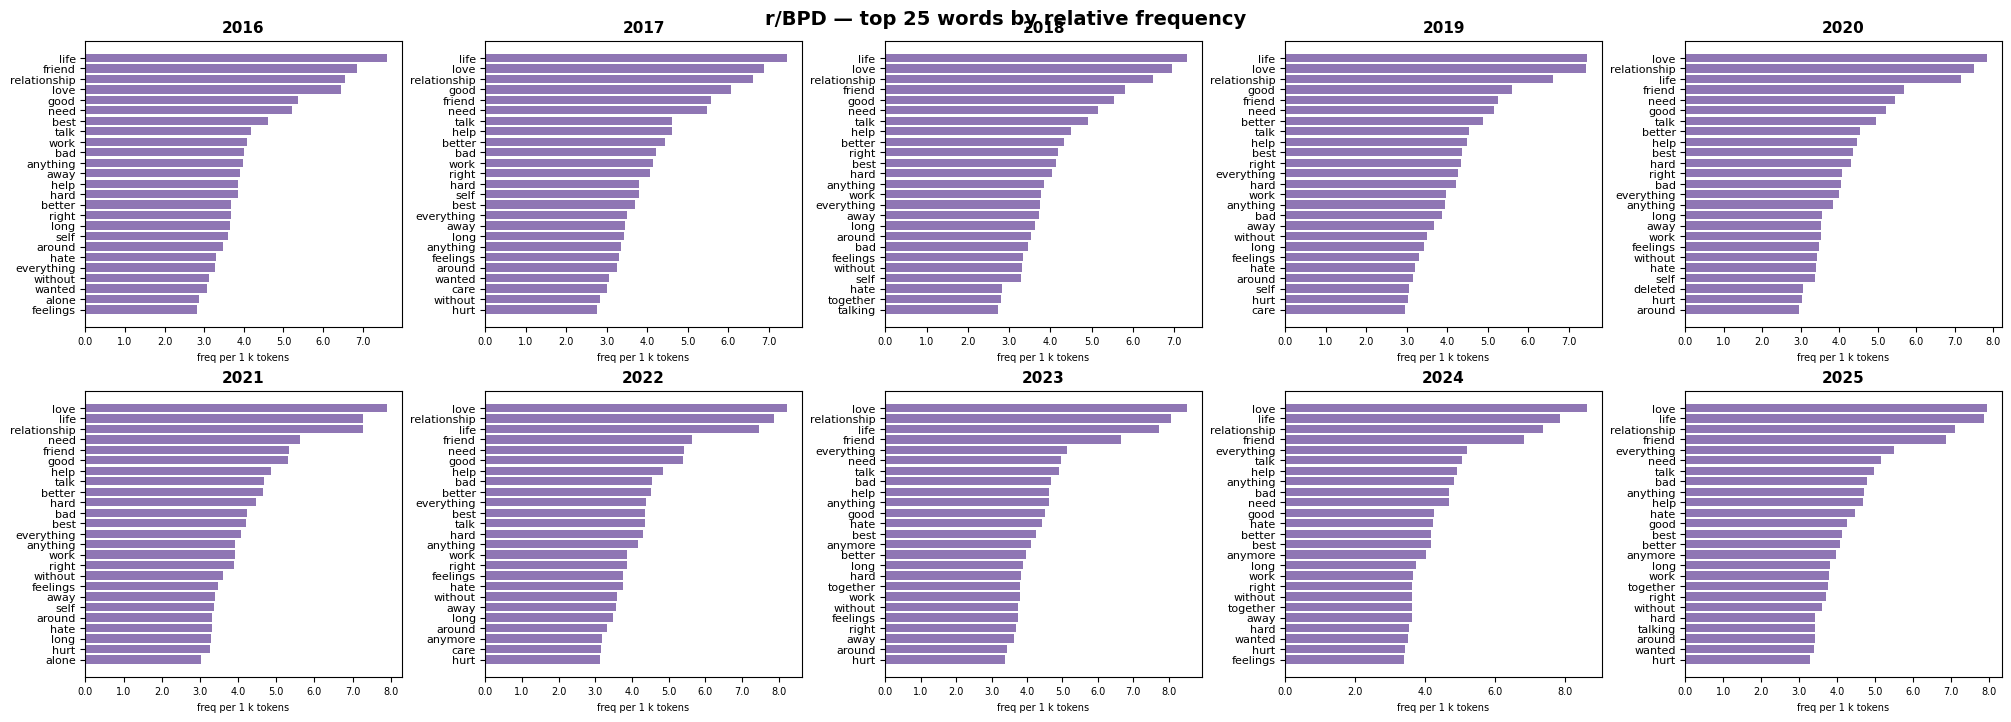

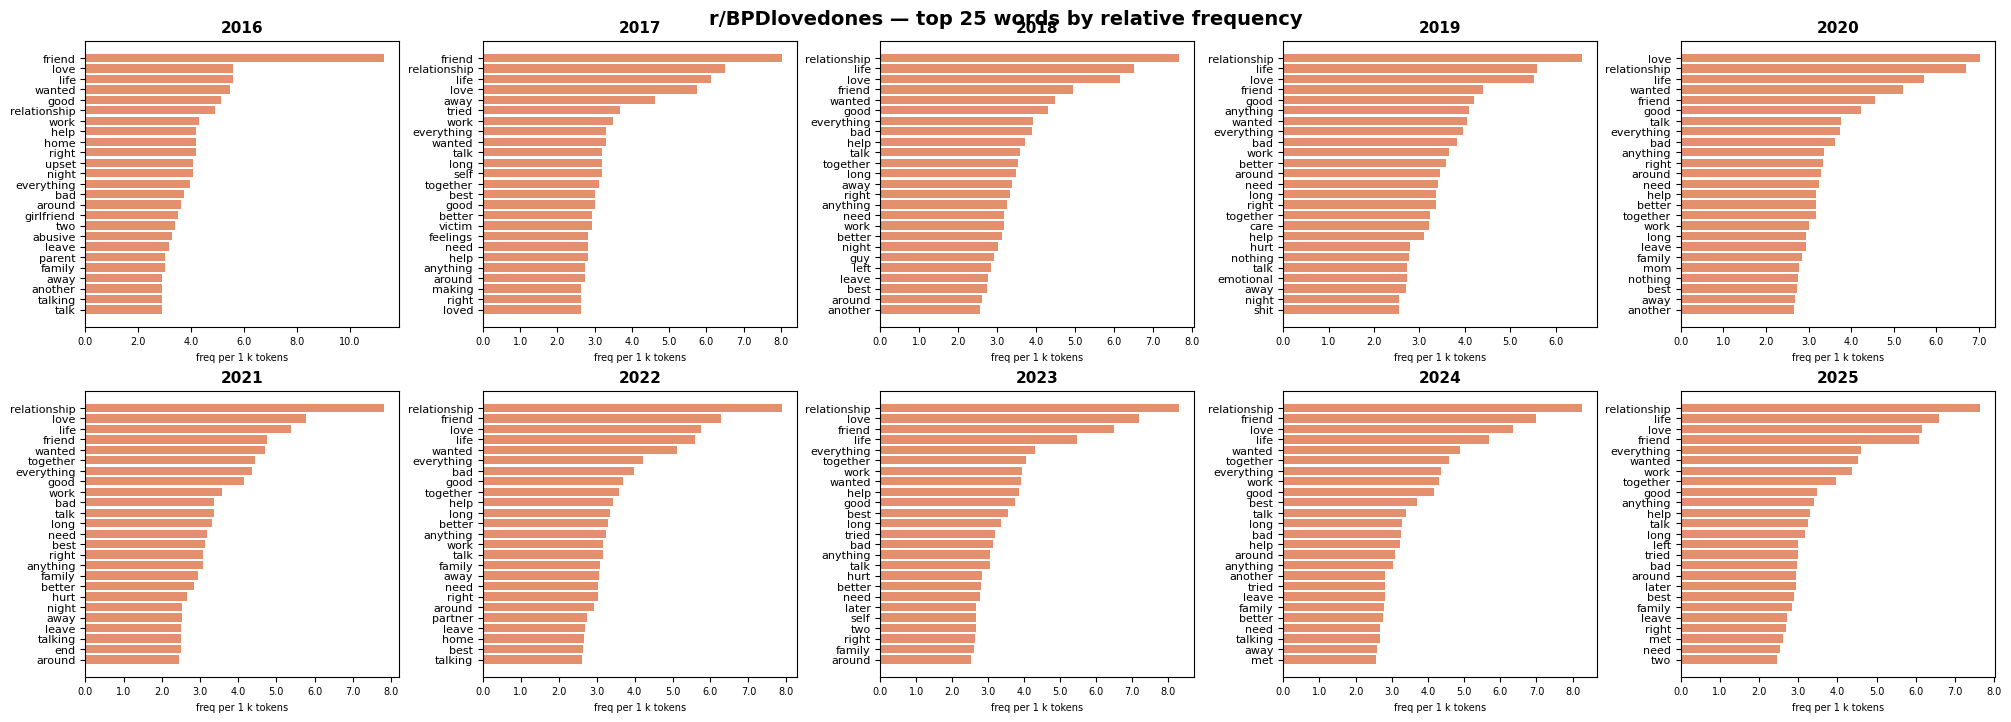

In [24]:
TOP_PLOT = 25  # bars per year panel

SUBREDDIT_COLORS = {"BPD": "#7b5ea7", "BPDlovedones": "#e07b54"}
YEARS = sorted(freq_df["year"].unique())

for subreddit in ["BPD", "BPDlovedones"]:
    sub_freq = freq_df[freq_df["subreddit"] == subreddit]
    years    = sorted(sub_freq["year"].unique())
    ncols    = 5
    nrows    = -(-len(years) // ncols)  # ceiling div

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 4, nrows * 3.5),
                             constrained_layout=True)
    axes = axes.flatten()
    color = SUBREDDIT_COLORS[subreddit]

    for i, year in enumerate(years):
        ax = axes[i]
        data = (sub_freq[sub_freq["year"] == year]
                .nlargest(TOP_PLOT, "rel_freq")
                .sort_values("rel_freq"))
        ax.barh(data["word"], data["rel_freq"] * 1000, color=color, alpha=0.85)
        ax.set_title(str(year), fontsize=11, fontweight="bold")
        ax.set_xlabel("freq per 1 k tokens", fontsize=7)
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
        ax.tick_params(axis="y", labelsize=8)
        ax.tick_params(axis="x", labelsize=7)

    # hide unused subplots
    for j in range(len(years), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"r/{subreddit} — top {TOP_PLOT} words by relative frequency",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.savefig(f"data/word_freq_bars_{subreddit}.png", dpi=120,
                bbox_inches="tight")
    plt.show()

### Sentiment & emotion analysis (GoEmotions)

In [25]:
# ── Load the GoEmotions classifier ────────────────────────────────────────────
from transformers import pipeline

emotion_classifier = pipeline(
    "text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=None,           # return all 27 emotion scores per post
)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6061.00it/s]
RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Batch-classify sampled posts (one-time run, ~20-25 min on CPU)

In [31]:
# ── Subsample: min(n, 1000) posts per (subreddit, year) ──────────────────────
from tqdm import tqdm
import numpy as np

samples = []
for _, g in df.groupby(["subreddit", "year"]):
    samples.append(g.sample(n=min(len(g), 1000), random_state=42))
sample = pd.concat(samples).reset_index(drop=True)
print(f"Sampled {len(sample)} posts from {len(df)} total")

# ── Classify the sample in batches with progress bar ─────────────────────────
texts = sample["text_combined"].str[:512].tolist()
batch_size = 32

results = []
for i in tqdm(range(0, len(texts), batch_size), desc="Classifying emotions"):
    batch = texts[i : i + batch_size]
    results.extend(emotion_classifier(batch))

print(f"\nDone — classified {len(results)} posts")

Sampled 13925 posts from 86145 total


Classifying emotions: 100%|██████████| 436/436 [1:04:16<00:00,  8.85s/it]


Done — classified 13925 posts


In [32]:
# ── Build emotion DataFrame with all 27 scores ──────────────────────────────
emotion_rows = []
for r in results:
    row = {item["label"]: round(item["score"], 4) for item in r}
    emotion_rows.append(row)

emotion_df = pd.DataFrame(emotion_rows)

# Attach post metadata (from sample, not full df)
emotion_df.insert(0, "id", sample["id"].values)
emotion_df.insert(1, "subreddit", sample["subreddit"].values)
emotion_df.insert(2, "year", sample["year"].values)

# Top emotion per post
emotion_cols = emotion_df.columns[3:]  # all columns after id/subreddit/year
emotion_df["top_emotion"] = emotion_df[emotion_cols].idxmax(axis=1)
emotion_df["top_score"]   = emotion_df[emotion_cols].max(axis=1)

emotion_df.to_csv("data/emotions_by_post.csv", index=False)
print(f"Exported {len(emotion_df)} rows × {emotion_df.shape[1]} columns to data/emotions_by_post.csv")
print(emotion_df.head(3))

Exported 13925 rows × 33 columns to data/emotions_by_post.csv
        id subreddit  year  disappointment    love  neutral  annoyance  \
0  d7pyh1c       BPD  2016          0.2832  0.1327   0.0940     0.0851   
1   53xefo       BPD  2016          0.0556  0.0382   0.0356     0.0102   
2  d75yxn8       BPD  2016          0.2124  0.0147   0.0412     0.0425   

   sadness  desire  realization  ...  remorse  nervousness  confusion    fear  \
0   0.0552  0.0463       0.0419  ...   0.0038       0.0032     0.0024  0.0021   
1   0.1363  0.0053       0.0829  ...   0.0086       0.6101     0.0544  0.3048   
2   0.7803  0.0035       0.0323  ...   0.0066       0.0241     0.0187  0.0131   

   caring  amusement  gratitude  curiosity     top_emotion  top_score  
0  0.0014     0.0013     0.0011     0.0008  disappointment     0.2832  
1  0.0498     0.0047     0.0022     0.0152     nervousness     0.6101  
2  0.0117     0.0016     0.0004     0.0119         sadness     0.7803  

[3 rows x 33 columns]


In [33]:
# ── Derive sentiment from top emotion ────────────────────────────────────────
POSITIVE = {"admiration","amusement","approval","caring","desire",
            "excitement","gratitude","joy","love","optimism","pride","relief"}
NEGATIVE = {"anger","annoyance","disappointment","disapproval","disgust",
            "embarrassment","fear","grief","nervousness","remorse","sadness"}

def emotion_to_sentiment(label):
    if label in POSITIVE: return "positive"
    if label in NEGATIVE: return "negative"
    return "neutral"

emotion_df["sentiment_label"] = emotion_df["top_emotion"].map(emotion_to_sentiment)

# ── Sentiment proportions by (subreddit, year) ──────────────────────────────
sentiment_counts = (
    emotion_df.groupby(["subreddit", "year", "sentiment_label"])
    .size()
    .reset_index(name="count")
)
year_totals = sentiment_counts.groupby(["subreddit", "year"])["count"].transform("sum")
sentiment_counts["prop"] = sentiment_counts["count"] / year_totals

sentiment_counts.to_csv("data/sentiment_props_by_year.csv", index=False)

# ── Emotion proportions by (subreddit, year) ────────────────────────────────
emotion_counts = (
    emotion_df.groupby(["subreddit", "year", "top_emotion"])
    .size()
    .reset_index(name="count")
)
year_totals_e = emotion_counts.groupby(["subreddit", "year"])["count"].transform("sum")
emotion_counts["prop"] = emotion_counts["count"] / year_totals_e

emotion_counts.to_csv("data/emotion_props_by_year.csv", index=False)

print("Exported data/sentiment_props_by_year.csv")
print("Exported data/emotion_props_by_year.csv")
print(f"\nSentiment distribution:\n{emotion_df['sentiment_label'].value_counts()}")
print(f"\nTop 10 emotions:\n{emotion_df['top_emotion'].value_counts().head(10)}")


Exported data/sentiment_props_by_year.csv
Exported data/emotion_props_by_year.csv

Sentiment distribution:
sentiment_label
negative    5665
neutral     5254
positive    3006
Name: count, dtype: int64

Top 10 emotions:
top_emotion
neutral           3060
sadness           2576
disappointment    1011
curiosity         1006
love               698
confusion          678
approval           560
fear               559
annoyance          558
realization        478
Name: count, dtype: int64


### Visualizations

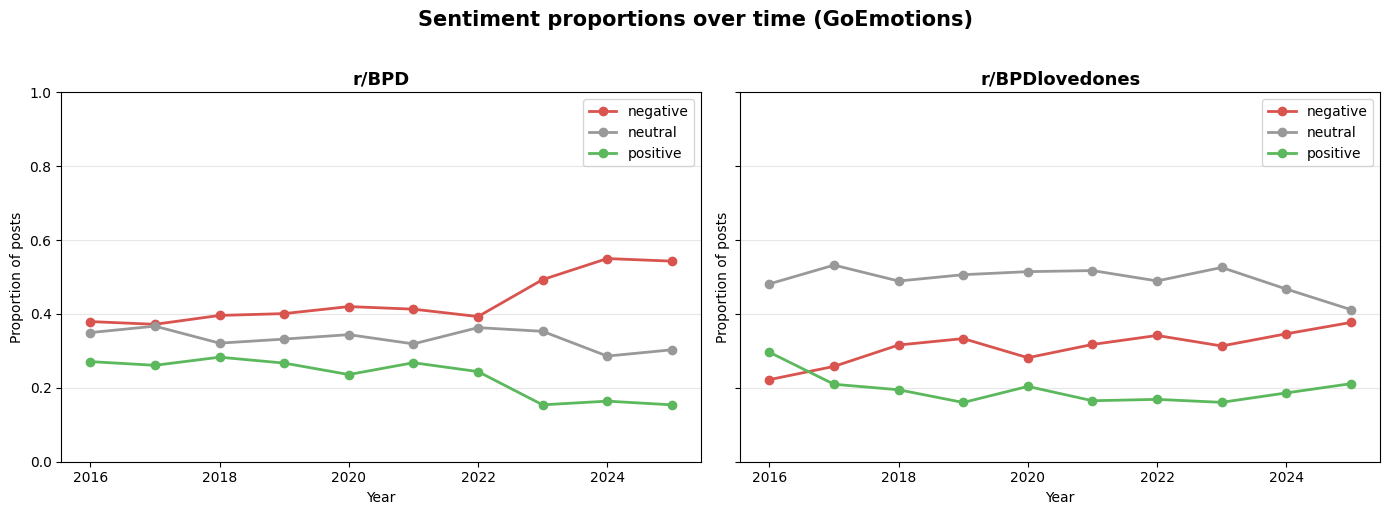

In [34]:
# ── Sentiment proportions over time ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, sub in zip(axes, ["BPD", "BPDlovedones"]):
    sub_data = sentiment_counts[sentiment_counts["subreddit"] == sub]
    for sentiment, color in [("negative", "#d9534f"), ("neutral", "#999999"), ("positive", "#5cb85c")]:
        s = sub_data[sub_data["sentiment_label"] == sentiment].sort_values("year")
        ax.plot(s["year"], s["prop"], marker="o", label=sentiment, color=color, linewidth=2)
    ax.set_title(f"r/{sub}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Proportion of posts")
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Sentiment proportions over time (GoEmotions)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data/sentiment_over_time.png", dpi=120, bbox_inches="tight")
plt.show()

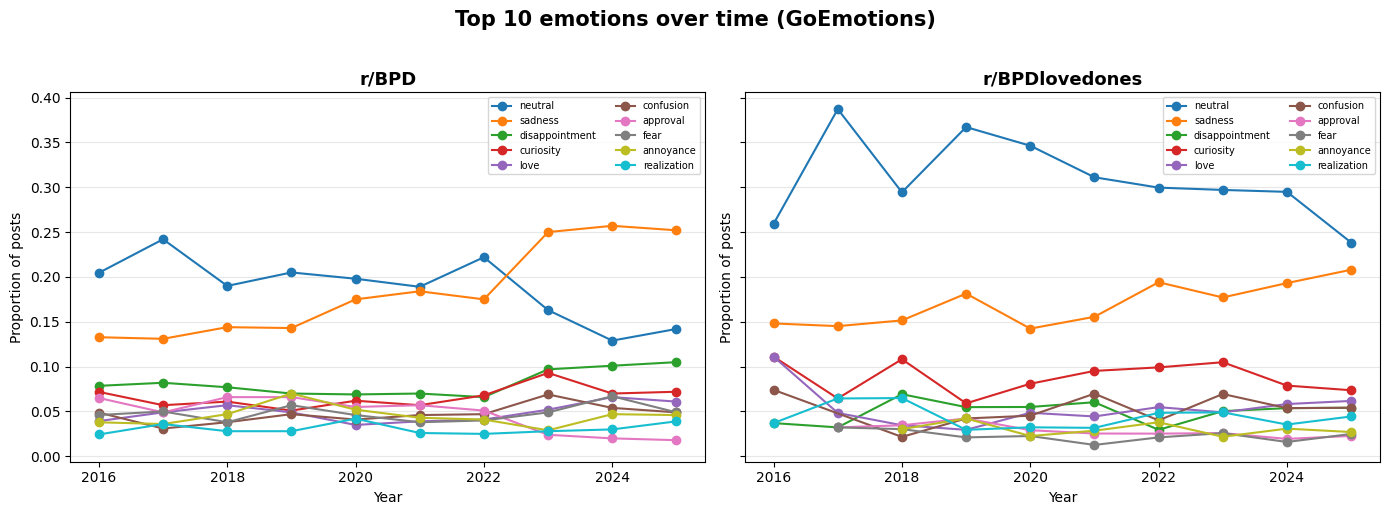

In [37]:
# ── Top emotions over time (top 10 by overall frequency) ─────────────────────
top_emotions = emotion_df["top_emotion"].value_counts().head(10).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, sub in zip(axes, ["BPD", "BPDlovedones"]):
    sub_data = emotion_counts[
        (emotion_counts["subreddit"] == sub) &
        (emotion_counts["top_emotion"].isin(top_emotions))
    ]
    for emo in top_emotions:
        e = sub_data[sub_data["top_emotion"] == emo].sort_values("year")
        ax.plot(e["year"], e["prop"], marker="o", label=emo, linewidth=1.5)
    ax.set_title(f"r/{sub}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Proportion of posts")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Top 10 emotions over time (GoEmotions)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data/emotions_over_time.png", dpi=120, bbox_inches="tight")
plt.show()

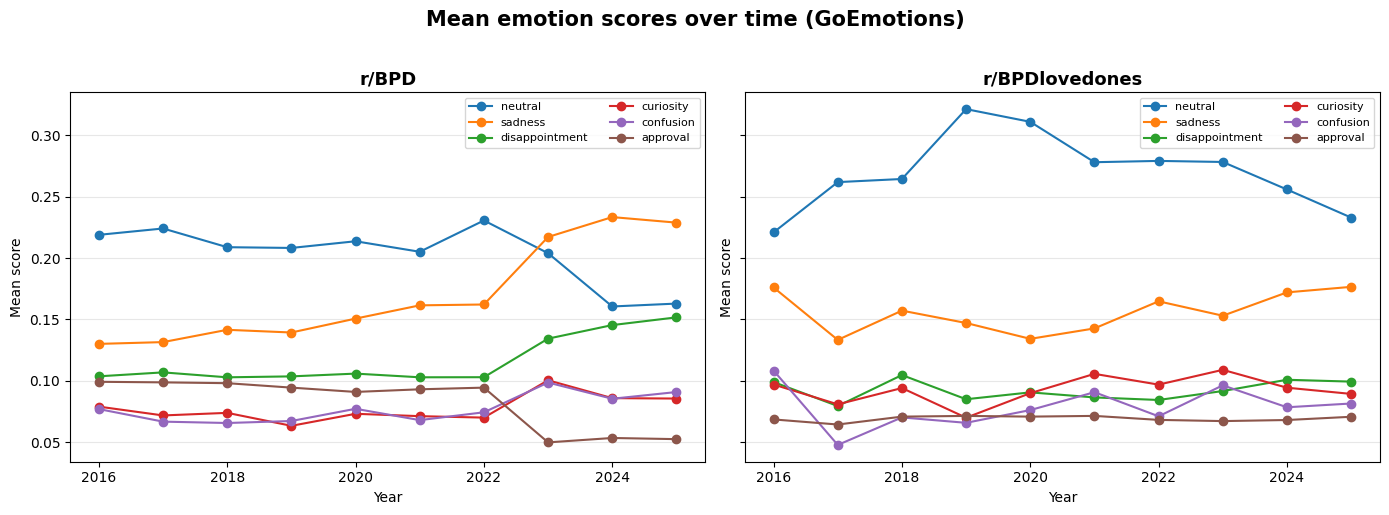

In [38]:
# ── Mean emotion scores over time (continuous signal, not just top-1) ────────
emotion_score_cols = [c for c in emotion_df.columns if c not in
                      {"id", "subreddit", "year", "top_emotion", "top_score", "sentiment_label"}]

mean_scores = (
    emotion_df.groupby(["subreddit", "year"])[emotion_score_cols]
    .mean()
    .reset_index()
)

# Pick the 6 emotions with the highest overall mean score
top_by_mean = mean_scores[emotion_score_cols].mean().nlargest(6).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, sub in zip(axes, ["BPD", "BPDlovedones"]):
    sub_data = mean_scores[mean_scores["subreddit"] == sub].sort_values("year")
    for emo in top_by_mean:
        ax.plot(sub_data["year"], sub_data[emo], marker="o", label=emo, linewidth=1.5)
    ax.set_title(f"r/{sub}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean score")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Mean emotion scores over time (GoEmotions)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data/mean_emotions_over_time.png", dpi=120, bbox_inches="tight")
plt.show()